# M1: Model Development & Experiment Tracking
## Binary Image Classification — Cats vs Dogs (Pet Adoption Platform)

**Objective:** Build baseline models, track experiments with MLflow, and version all artifacts using Git + DVC.

### Tasks Covered:
1. **Data & Code Versioning** — Git for source code, DVC for dataset versioning  
2. **Model Building** — Custom CNN (~10M params)  
3. **Experiment Tracking** — MLflow for logging runs, parameters, metrics, and artifacts

**Dataset:** [Kaggle Cats and Dogs Classification Dataset](https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset)  
**Pre-processing:** 224×224 RGB images for standard CNNs

## 1. Install and Import Dependencies
Install all required packages for the project.

In [1]:
# Install required packages
!pip install torch torchvision torchsummary mlflow dvc scikit-learn matplotlib seaborn numpy pandas pillow onnx -q

In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as transforms
from torchsummary import summary

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

import mlflow
import mlflow.pytorch

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"MLflow version: {mlflow.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128
MLflow version: 3.8.1


## 2. Configure DVC for Dataset Versioning

DVC (Data Version Control) allows us to version large datasets alongside Git.  
We initialize DVC inside our Git repository and track the raw dataset directory.

In [4]:
# ── Project directory setup ──
PROJECT_ROOT = os.getcwd()
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
RAW_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
ARTIFACTS_DIR = os.path.join(PROJECT_ROOT, "artifacts")

for d in [DATA_DIR, RAW_DIR, PROCESSED_DIR, MODELS_DIR, ARTIFACTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Project structure created:")
for d in [DATA_DIR, RAW_DIR, PROCESSED_DIR, MODELS_DIR, ARTIFACTS_DIR]:
    print(f"  {os.path.relpath(d, PROJECT_ROOT)}")

Project structure created:
  data
  data/raw
  data/processed
  models
  artifacts


In [5]:
# ── Initialize Git and DVC ──
# Run these commands in the terminal (uncomment to execute from notebook)

!git init
!dvc init

# Add raw dataset to DVC tracking
# After downloading the dataset into data/raw/:
# !dvc add data/raw
# This creates data/raw.dvc (pointer file) and updates .gitignore

print("Git and DVC initialized.")
print("After downloading data, run:")
print("  dvc add data/raw")
print("  git add data/raw.dvc data/.gitignore")
print("  git commit -m 'Add raw dataset with DVC tracking'")

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /home/noiclt45353/Workspace/Others/Assign2/.git/
Initialized DVC repository.

You can now commit the changes to git.

+---------------------------------------------------------------------+
|                                                                     |
|        DVC has enabled anonymous aggregate usage analytics.         |
|     Read the analytics documentation (and how to opt-out) here:     |
|             <https://dvc.org/doc/user-guide/analytics>              |
|

## 3. Load and Explore the Cats vs Dogs Dataset

Downloaded the **Microsoft Cats vs Dogs** dataset from Kaggle.  
The dataset contains 25,000 images of cats and dogs (12,500 each).  
Files are named `cat.XXXX.jpg` / `dog.XXXX.jpg`.

In [6]:
# ── Download dataset ──
# Option 1: Using Kaggle API (requires kaggle.json credentials)
# !kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset -p data/raw --unzip

# Option 2: Direct download using urllib (Microsoft hosted)
import urllib.request
import zipfile

DATASET_URL = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
ZIP_PATH = os.path.join(DATA_DIR, "kagglecatsanddogs_5340.zip")

if not os.path.exists(os.path.join(RAW_DIR, "PetImages")):
    print("Downloading Cats vs Dogs dataset...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(RAW_DIR)
    os.remove(ZIP_PATH)
    print("Download and extraction complete!")
else:
    print("Dataset already exists.")

CAT_DIR = os.path.join(RAW_DIR, "PetImages", "Cat")
DOG_DIR = os.path.join(RAW_DIR, "PetImages", "Dog")
print(f"\nCat images: {len(os.listdir(CAT_DIR))}")
print(f"Dog images: {len(os.listdir(DOG_DIR))}")

Extracting...
Download and extraction complete!

Cat images: 12501
Dog images: 12501


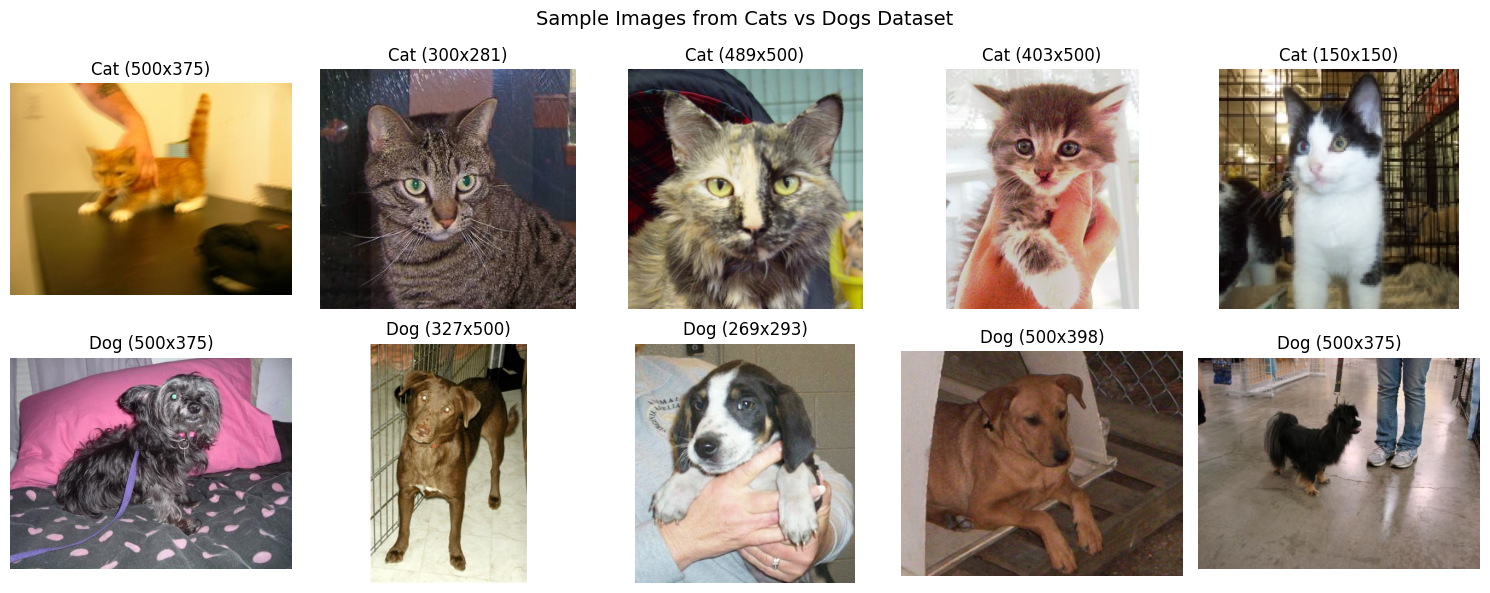

In [7]:
# ── Explore: Display sample images ──
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Images from Cats vs Dogs Dataset", fontsize=14)

for i, ax in enumerate(axes[0]):
    img_name = sorted(os.listdir(CAT_DIR))[i]
    img = Image.open(os.path.join(CAT_DIR, img_name)).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"Cat ({img.size[0]}x{img.size[1]})")
    ax.axis("off")

for i, ax in enumerate(axes[1]):
    img_name = sorted(os.listdir(DOG_DIR))[i]
    img = Image.open(os.path.join(DOG_DIR, img_name)).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"Dog ({img.size[0]}x{img.size[1]})")
    ax.axis("off")

plt.tight_layout()
plt.show()

Dataset Statistics:
  Total images : 25000
  Cat images   : 12500 (50.0%)
  Dog images   : 12500 (50.0%)


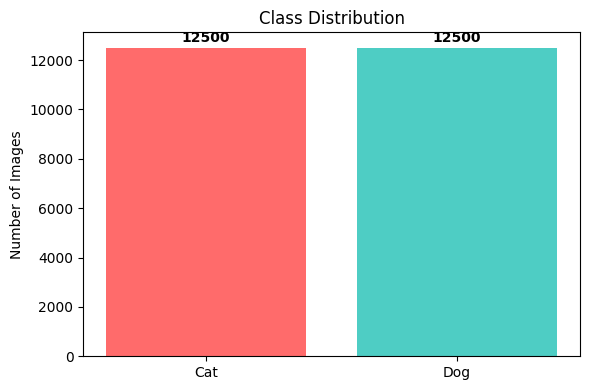


Image Size Distribution (sampled):
  Width  — min: 60, max: 500, mean: 403
  Height — min: 36, max: 500, mean: 363


/home/noiclt45353/.local/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [8]:
# ── Dataset statistics & class distribution ──
cat_count = len([f for f in os.listdir(CAT_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))])
dog_count = len([f for f in os.listdir(DOG_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))])
total = cat_count + dog_count

print(f"Dataset Statistics:")
print(f"  Total images : {total}")
print(f"  Cat images   : {cat_count} ({cat_count/total*100:.1f}%)")
print(f"  Dog images   : {dog_count} ({dog_count/total*100:.1f}%)")

# Class distribution bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Cat", "Dog"], [cat_count, dog_count], color=["#FF6B6B", "#4ECDC4"])
ax.set_ylabel("Number of Images")
ax.set_title("Class Distribution")
for bar, count in zip(bars, [cat_count, dog_count]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Sample image size distribution ──
widths, heights = [], []
for cls_dir in [CAT_DIR, DOG_DIR]:
    for fname in random.sample(os.listdir(cls_dir), min(500, len(os.listdir(cls_dir)))):
        try:
            img = Image.open(os.path.join(cls_dir, fname))
            widths.append(img.size[0])
            heights.append(img.size[1])
        except:
            continue

print(f"\nImage Size Distribution (sampled):")
print(f"  Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"  Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

## 4. Data Preprocessing — Resize to 224×224 RGB

All images are resized to **224×224** pixels, converted to 3-channel RGB, and normalized using ImageNet statistics.  
Corrupt/unreadable images are filtered out during loading.

In [9]:
# ── Custom Dataset class with corrupt image handling ──
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class CatsDogsDataset(Dataset):
    """Custom PyTorch Dataset for Cats vs Dogs classification."""
    
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

# ── Collect valid file paths and labels ──
file_paths = []
labels = []     # 0 = Cat, 1 = Dog
corrupt_count = 0

for cls_name, cls_dir, label in [("Cat", CAT_DIR, 0), ("Dog", DOG_DIR, 1)]:
    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        try:
            img = Image.open(fpath)
            img.verify()  # Check for corruption
            file_paths.append(fpath)
            labels.append(label)
        except Exception:
            corrupt_count += 1

print(f"Valid images: {len(file_paths)}")
print(f"Corrupt/skipped images: {corrupt_count}")

Valid images: 24998
Corrupt/skipped images: 4


## 5. Data Augmentation and DataLoader Setup

**Training augmentations:** RandomHorizontalFlip, RandomRotation, ColorJitter  
**Validation/Test:** Only resize and normalize  
**Split:** 70% train / 15% validation / 15% test

In [10]:
# ── Transforms ──
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Train / Validation / Test split (70/15/15) ──
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    file_paths, labels, test_size=0.30, random_state=SEED, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Train class dist: {Counter(y_train)}")
print(f"Val   class dist: {Counter(y_val)}")
print(f"Test  class dist: {Counter(y_test)}")

# ── Create Datasets & DataLoaders ──
BATCH_SIZE = 32

train_dataset = CatsDogsDataset(X_train, y_train, transform=train_transform)
val_dataset   = CatsDogsDataset(X_val, y_val, transform=val_test_transform)
test_dataset  = CatsDogsDataset(X_test, y_test, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Verify a batch
images, lbls = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}, Labels shape: {lbls.shape}")
print(f"Label sample: {lbls[:10].tolist()}")

Train: 17498 | Val: 3750 | Test: 3750
Train class dist: Counter({1: 8749, 0: 8749})
Val   class dist: Counter({1: 1875, 0: 1875})
Test  class dist: Counter({1: 1875, 0: 1875})

Batch shape: torch.Size([32, 3, 224, 224]), Labels shape: torch.Size([32])
Label sample: [0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0]


## 6. Git and DVC Version Control Setup

Below are the Git + DVC commands to version control the project structure, preprocessed data, and pipeline stages.

In [11]:
# ── Git: Version control for source code ──
# !git add M1_CatsVsDogs_MLOps.ipynb
# !git commit -m "Add baseline notebook for Cats vs Dogs classification"

# ── DVC: Track preprocessed data ──
# !dvc add data/processed
# !git add data/processed.dvc data/.gitignore

# ── DVC Pipeline (dvc.yaml) ──
# Create pipeline stages linking preprocessing to data outputs
dvc_yaml_content = """
stages:
  preprocess:
    cmd: python scripts/preprocess.py
    deps:
      - data/raw/PetImages
      - scripts/preprocess.py
    outs:
      - data/processed

  train_cnn:
    cmd: python scripts/train_cnn.py
    deps:
      - data/processed
      - scripts/train_cnn.py
    outs:
      - models/cnn_model.pt
    metrics:
      - metrics/cnn_metrics.json:
          cache: false

"""

with open("dvc.yaml", "w") as f:
    f.write(dvc_yaml_content)

print("dvc.yaml pipeline file created.")
print("\nDVC commands reference:")
print("  dvc repro           — Reproduce the full pipeline")
print("  dvc push            — Push data to remote storage")
print("  dvc pull            — Pull data from remote storage")
print("  dvc diff            — Show changes in tracked data")

# ── Configure DVC remote (example with local storage) ──
# !dvc remote add -d myremote /path/to/remote/storage
# !dvc push

dvc.yaml pipeline file created.

DVC commands reference:
  dvc repro           — Reproduce the full pipeline
  dvc push            — Push data to remote storage
  dvc pull            — Pull data from remote storage
  dvc diff            — Show changes in tracked data


## 7. Initialize MLflow Experiment Tracking

Set up MLflow to log all experiments, parameters, metrics, and artifacts.  
We create a dedicated experiment named `cats-vs-dogs-classification`.

In [12]:
# ── MLflow Setup ──
MLFLOW_TRACKING_URI = "mlruns"  # Local tracking directory
EXPERIMENT_NAME = "cats-vs-dogs-classification"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment Name     : {EXPERIMENT_NAME}")
print(f"Experiment ID       : {mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id}")

# ── Helper functions for logging ──
def log_confusion_matrix(y_true, y_pred, title, filename):
    """Generate, display, and save a confusion matrix plot."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    plt.tight_layout()
    filepath = os.path.join(ARTIFACTS_DIR, filename)
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    return filepath

def log_curves(train_losses, val_losses, train_accs, val_accs, prefix):
    """Plot and save training curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = range(1, len(train_losses) + 1)
    ax1.plot(epochs, train_losses, 'b-o', label='Train Loss', markersize=4)
    ax1.plot(epochs, val_losses, 'r-o', label='Val Loss', markersize=4)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{prefix} — Loss Curves')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(epochs, train_accs, 'b-o', label='Train Accuracy', markersize=4)
    ax2.plot(epochs, val_accs, 'r-o', label='Val Accuracy', markersize=4)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{prefix} — Accuracy Curves')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    filepath = os.path.join(ARTIFACTS_DIR, f"{prefix}_curves.png")
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    return filepath

print("MLflow experiment and helper functions ready.")

/home/noiclt45353/.local/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2026/02/20 21:55:25 INFO mlflow.tracking.fluent: Experiment with name 'cats-vs-dogs-classification' does not exist. Creating a new experiment.


MLflow Tracking URI : mlruns
Experiment Name     : cats-vs-dogs-classification
Experiment ID       : 882457561328237474
MLflow experiment and helper functions ready.


## 8. Build Baseline Model — Simple CNN (~10M Parameters)

A custom CNN with multiple convolutional blocks (Conv2d → BatchNorm → ReLU → MaxPool2d) followed by fully connected layers, targeting approximately **10M parameters**.

In [13]:
# ── CNN Architecture (~10M params) ──
class CatsDogsCNN(nn.Module):
    """Simple CNN for binary classification targeting ~10M parameters."""
    
    def __init__(self):
        super(CatsDogsCNN, self).__init__()
        
        # Convolutional blocks
        self.features = nn.Sequential(
            # Block 1: 3 → 32 channels, 224→112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 2: 32 → 64 channels, 112→56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 3: 64 → 128 channels, 56→28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 4: 128 → 256 channels, 28→14
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 5: 256 → 512 channels, 14→7
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 512),   # 512*49 = 25088 → 512
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 1),              # Binary output (logit)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)

# ── Instantiate and inspect ──
cnn_model = CatsDogsCNN().to(device)

# Model summary
print("=" * 60)
print("CNN Model Architecture")
print("=" * 60)
summary(cnn_model, (3, IMG_SIZE, IMG_SIZE))

total_params = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"≈ {total_params / 1e6:.2f}M parameters")

CNN Model Architecture
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
       BatchNorm2d-2         [-1, 32, 224, 224]              64
              ReLU-3         [-1, 32, 224, 224]               0
         MaxPool2d-4         [-1, 32, 112, 112]               0
            Conv2d-5         [-1, 64, 112, 112]          18,496
       BatchNorm2d-6         [-1, 64, 112, 112]             128
              ReLU-7         [-1, 64, 112, 112]               0
         MaxPool2d-8           [-1, 64, 56, 56]               0
            Conv2d-9          [-1, 128, 56, 56]          73,856
      BatchNorm2d-10          [-1, 128, 56, 56]             256
             ReLU-11          [-1, 128, 56, 56]               0
        MaxPool2d-12          [-1, 128, 28, 28]               0
           Conv2d-13          [-1, 256, 28, 28]         295,168
      BatchNorm2

## 9. Train CNN with MLflow Logging (Parameters, Metrics, Loss Curves)

Train the CNN using **BCEWithLogitsLoss** and **Adam** optimizer with epoch-level logging of train/val loss and accuracy to MLflow.

In [14]:
# ── Training configuration ──
NUM_EPOCHS = 10
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# ── Training loop with MLflow ──
with mlflow.start_run(run_name="CNN_Baseline") as run:
    cnn_run_id = run.info.run_id
    
    # Log hyperparameters
    cnn_params = {
        "model_type": "CNN",
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "optimizer": "Adam",
        "loss_function": "BCEWithLogitsLoss",
        "scheduler": "ReduceLROnPlateau",
        "image_size": IMG_SIZE,
        "total_params": total_params,
        "n_train_samples": len(train_dataset),
        "n_val_samples": len(val_dataset),
    }
    mlflow.log_params(cnn_params)
    
    # Storage for curves
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_loss = float('inf')
    
    for epoch in range(1, NUM_EPOCHS + 1):
        # ── Training phase ──
        cnn_model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for batch_idx, (images, labels_batch) in enumerate(train_loader):
            images, labels_batch = images.to(device), labels_batch.to(device)
            
            optimizer.zero_grad()
            outputs = cnn_model(images)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels_batch).sum().item()
            total += labels_batch.size(0)
        
        train_loss = running_loss / total
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # ── Validation phase ──
        cnn_model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels_batch in val_loader:
                images, labels_batch = images.to(device), labels_batch.to(device)
                outputs = cnn_model(images)
                loss = criterion(outputs, labels_batch)
                
                val_running_loss += loss.item() * images.size(0)
                preds = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (preds == labels_batch).sum().item()
                val_total += labels_batch.size(0)
        
        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # Step scheduler
        scheduler.step(val_loss)
        
        # Log epoch metrics to MLflow
        mlflow.log_metrics({
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "learning_rate": optimizer.param_groups[0]['lr'],
        }, step=epoch)
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(cnn_model.state_dict(), os.path.join(MODELS_DIR, "cnn_best.pt"))
        
        print(f"Epoch [{epoch}/{NUM_EPOCHS}] | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    print(f"\nTraining complete! Best val loss: {best_val_loss:.4f}")
    print(f"MLflow Run ID: {cnn_run_id}")

/home/noiclt45353/.local/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [1/10] | Train Loss: 0.7550, Acc: 0.5374 | Val Loss: 0.6540, Acc: 0.6024 | LR: 0.001000


/home/noiclt45353/.local/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [2/10] | Train Loss: 0.6385, Acc: 0.6236 | Val Loss: 0.5756, Acc: 0.6824 | LR: 0.001000


/home/noiclt45353/.local/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


...

Epoch [8/10] | Train Loss: 0.2962, Acc: 0.8729 | Val Loss: 0.2406, Acc: 0.9029 | LR: 0.001000


/home/noiclt45353/.local/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [9/10] | Train Loss: 0.2531, Acc: 0.8956 | Val Loss: 0.1874, Acc: 0.9259 | LR: 0.001000


/home/noiclt45353/.local/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [10/10] | Train Loss: 0.2275, Acc: 0.9078 | Val Loss: 0.2095, Acc: 0.9165 | LR: 0.001000

Training complete! Best val loss: 0.1874
MLflow Run ID: 6f8e4d91fb9a499f864f7fdb0f66c232


## 10. Evaluate CNN — Confusion Matrix and Classification Report

Run inference on the test set and compute all evaluation metrics. Generate a confusion matrix heatmap and display sample predictions.

── CNN Test Results ──
  test_accuracy: 0.9179
  test_precision: 0.9233
  test_recall: 0.9115
  test_f1: 0.9173
  test_auc_roc: 0.9759

Classification Report (Test Set):
              precision    recall  f1-score   support

         Cat       0.91      0.92      0.92      1875
         Dog       0.92      0.91      0.92      1875

    accuracy                           0.92      3750
   macro avg       0.92      0.92      0.92      3750
weighted avg       0.92      0.92      0.92      3750



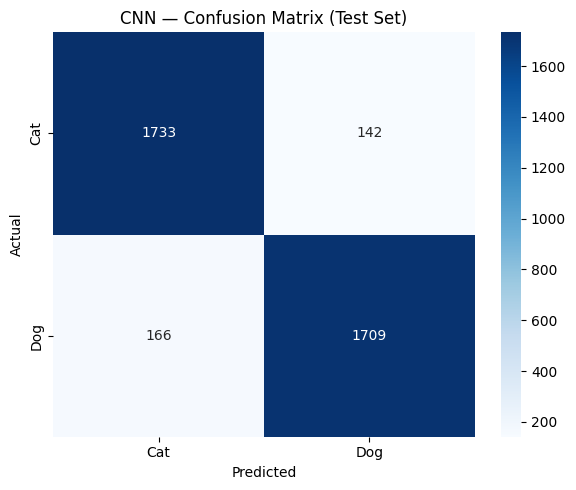

In [15]:
# ── Load best model and evaluate on test set ──
cnn_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "cnn_best.pt"), map_location=device))
cnn_model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels_batch in test_loader:
        images = images.to(device)
        outputs = cnn_model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels_batch.numpy().astype(int))

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# ── Metrics ──
cnn_test_metrics = {
    "test_accuracy": accuracy_score(all_labels, all_preds),
    "test_precision": precision_score(all_labels, all_preds),
    "test_recall": recall_score(all_labels, all_preds),
    "test_f1": f1_score(all_labels, all_preds),
    "test_auc_roc": roc_auc_score(all_labels, all_probs),
}

print("── CNN Test Results ──")
for k, v in cnn_test_metrics.items():
    print(f"  {k}: {v:.4f}")

# Classification report
print("\nClassification Report (Test Set):")
cnn_report = classification_report(all_labels, all_preds, target_names=["Cat", "Dog"])
print(cnn_report)

# ── Confusion matrix ──
cm_path = log_confusion_matrix(all_labels, all_preds,
                                "CNN — Confusion Matrix (Test Set)",
                                "cnn_confusion_matrix.png")

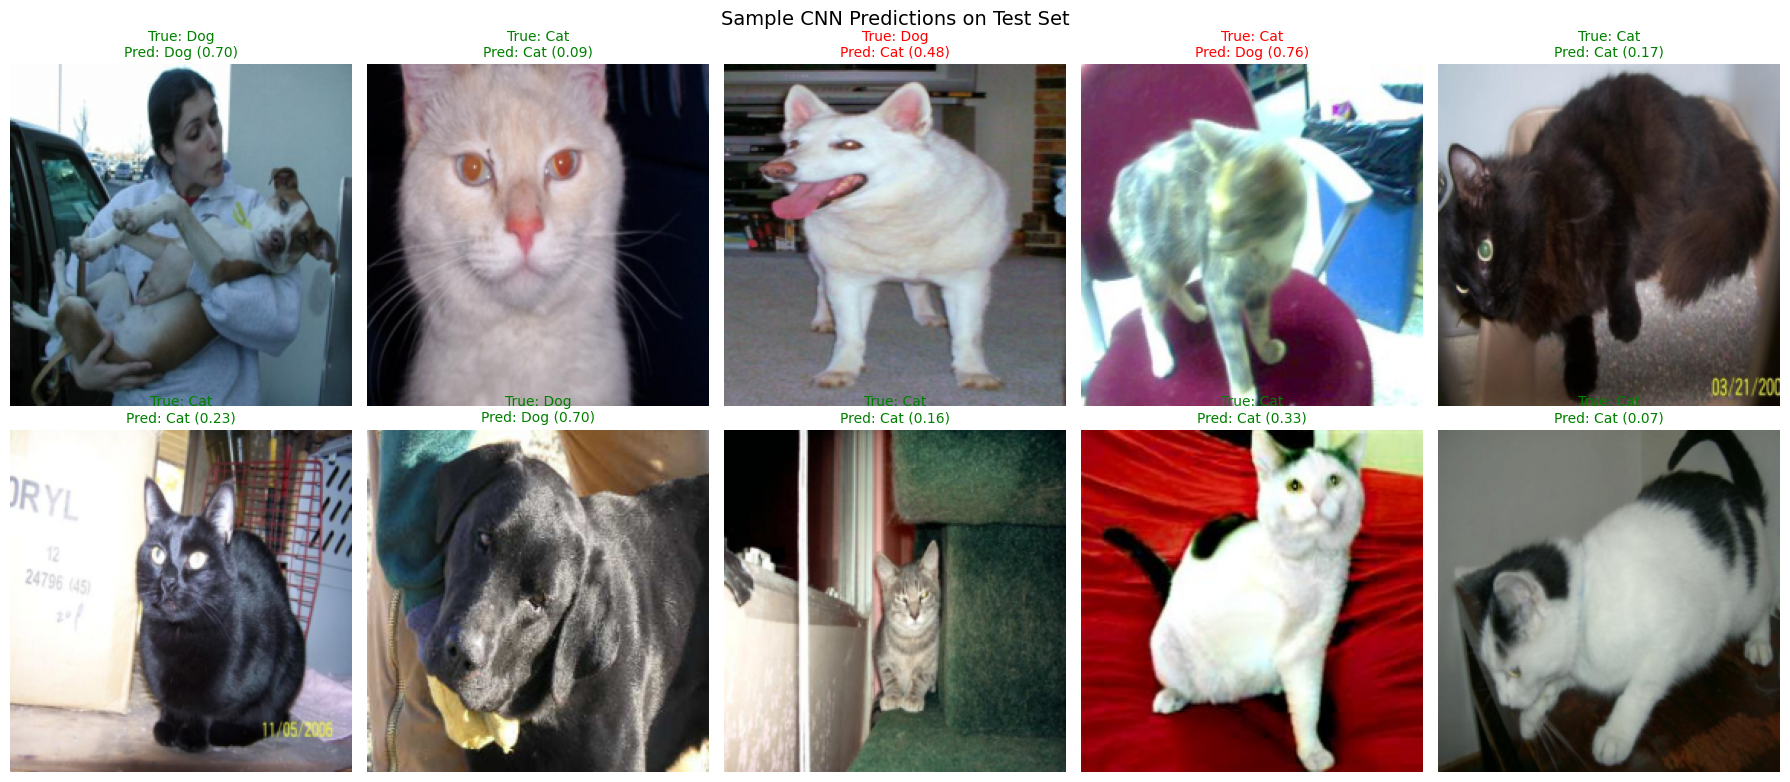

In [16]:
# ── Display sample predictions ──
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle("Sample CNN Predictions on Test Set", fontsize=14)

# De-normalize for visualization
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)

sample_indices = random.sample(range(len(test_dataset)), 10)
class_names = ["Cat", "Dog"]

for i, idx in enumerate(sample_indices):
    ax = axes[i // 5][i % 5]
    img, label = test_dataset[idx]
    
    # Predict
    with torch.no_grad():
        output = cnn_model(img.unsqueeze(0).to(device))
        prob = torch.sigmoid(output).item()
        pred = 1 if prob > 0.5 else 0
    
    # De-normalize and display
    img_display = inv_normalize(img).permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img_display)
    
    color = "green" if pred == int(label.item()) else "red"
    ax.set_title(f"True: {class_names[int(label.item())]}\nPred: {class_names[pred]} ({prob:.2f})",
                 color=color, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 11. Log Artifacts to MLflow (Confusion Matrix, Loss Curves, Model)

Save and log all training artifacts — loss/accuracy curves, confusion matrix, classification report, and the trained PyTorch model — to MLflow.

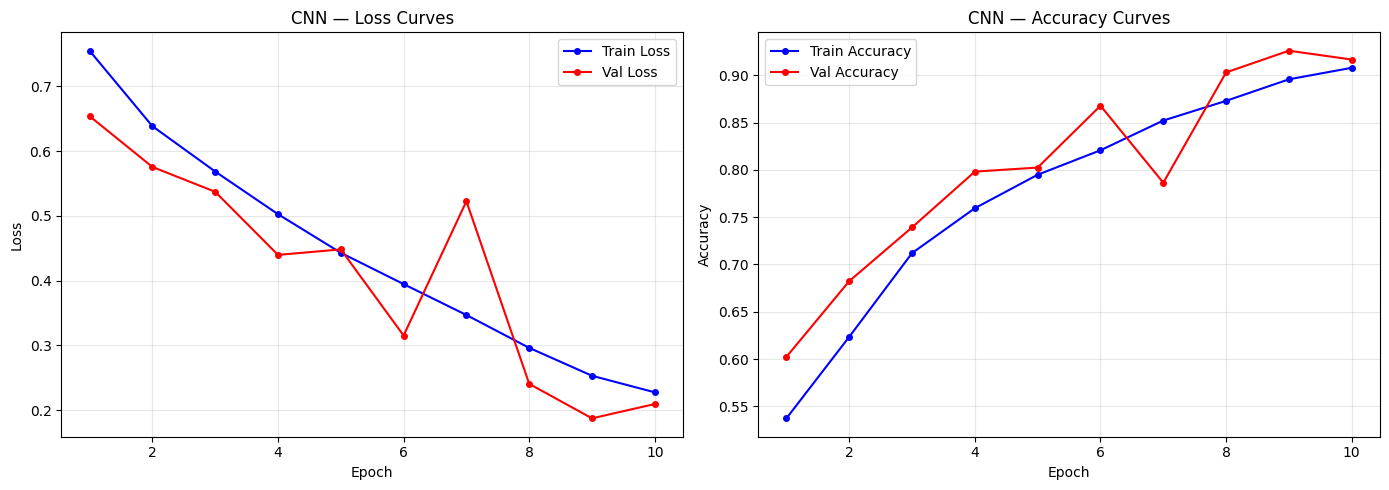

2026/02/20 22:09:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


All CNN artifacts logged to MLflow:
  - Loss/accuracy curves: /home/noiclt45353/Workspace/Others/Assign2/artifacts/CNN_curves.png
  - Confusion matrix: cnn_confusion_matrix.png
  - Classification report: cnn_classification_report.txt
  - PyTorch model: cnn_model/
  - Run ID: 6f8e4d91fb9a499f864f7fdb0f66c232


In [17]:
# ── Log all CNN artifacts to MLflow ──
with mlflow.start_run(run_id=cnn_run_id):
    # Log test metrics
    mlflow.log_metrics(cnn_test_metrics)
    
    # 1. Loss and accuracy curves
    curves_path = log_curves(train_losses, val_losses, train_accs, val_accs, "CNN")
    mlflow.log_artifact(curves_path)
    
    # 2. Confusion matrix
    mlflow.log_artifact(os.path.join(ARTIFACTS_DIR, "cnn_confusion_matrix.png"))
    
    # 3. Classification report
    cnn_report_path = os.path.join(ARTIFACTS_DIR, "cnn_classification_report.txt")
    with open(cnn_report_path, "w") as f:
        f.write(cnn_report)
    mlflow.log_artifact(cnn_report_path)
    
    # 4. Log the trained PyTorch model
    # Load best model for logging
    cnn_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "cnn_best.pt"), map_location=device))
    mlflow.pytorch.log_model(cnn_model, "cnn_model")
    
    print("All CNN artifacts logged to MLflow:")
    print(f"  - Loss/accuracy curves: {curves_path}")
    print(f"  - Confusion matrix: cnn_confusion_matrix.png")
    print(f"  - Classification report: cnn_classification_report.txt")
    print(f"  - PyTorch model: cnn_model/")
    print(f"  - Run ID: {cnn_run_id}")

## 12. Save Models in Serialized Formats (.pt)

Save the CNN model in standard serialized formats for deployment and reproducibility:
- **CNN state_dict:** `.pt`
- **CNN full model:** `.pt`
- **ONNX export** for interoperability

In [23]:
import joblib

# ── Save CNN model (.pt — state_dict) ──
cnn_state_dict_path = os.path.join(MODELS_DIR, "cnn_model.pt")
torch.save(cnn_model.state_dict(), cnn_state_dict_path)
print(f"\nCNN state_dict saved: {cnn_state_dict_path}")
print(f"  File size: {os.path.getsize(cnn_state_dict_path) / 1e6:.2f} MB")

# ── Save CNN full model (.pt) ──
cnn_full_path = os.path.join(MODELS_DIR, "cnn_model_full.pt")
torch.save(cnn_model, cnn_full_path)
print(f"\nCNN full model saved: {cnn_full_path}")
print(f"  File size: {os.path.getsize(cnn_full_path) / 1e6:.2f} MB")

# ── Export CNN to ONNX ──
try:
    import onnx
    onnx_path = os.path.join(MODELS_DIR, "cnn_model.onnx")
    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    torch.onnx.export(cnn_model, dummy_input, onnx_path,
                      input_names=['image'], output_names=['prediction'],
                      dynamic_axes={'image': {0: 'batch'}, 'prediction': {0: 'batch'}})
    print(f"\nCNN ONNX exported: {onnx_path}")
    print(f"  File size: {os.path.getsize(onnx_path) / 1e6:.2f} MB")
except ImportError:
    print("\nONNX export skipped (install onnx package)")


# # Verify LR
# lr_loaded = joblib.load(lr_model_path)
# sample_pred = lr_loaded.predict(X_test_flat[:1])
# print(f"LR loaded successfully. Sample prediction: {class_names[sample_pred[0]]}")

# Verify CNN
# Verify CNN
cnn_loaded = CatsDogsCNN().to(device)
cnn_loaded.load_state_dict(torch.load(cnn_state_dict_path, map_location=device))
cnn_loaded.eval()
with torch.no_grad():
    sample_img = test_dataset[0][0].unsqueeze(0).to(device)
    sample_out = torch.sigmoid(cnn_loaded(sample_img)).item()


CNN state_dict saved: /home/noiclt45353/Workspace/Others/Assign2/models/cnn_model.pt
  File size: 57.95 MB

CNN full model saved: /home/noiclt45353/Workspace/Others/Assign2/models/cnn_model_full.pt
  File size: 57.96 MB

ONNX export skipped (install onnx package)


## 13. Version Trained Models and Preprocessed Data with DVC

Track model artifacts with DVC and integrate into the pipeline for full reproducibility.

In [24]:
# ── DVC: Track trained models ──
# Add model directory to DVC
# !dvc add models/

# ── DVC: Track preprocessed data ──
# !dvc add data/processed/

# ── Git: Commit DVC tracking files ──
# !git add models.dvc data/processed.dvc .gitignore
# !git add dvc.yaml dvc.lock
# !git commit -m "Track trained models and preprocessed data with DVC"

# ── Reproduce the full pipeline ──
# !dvc repro

# ── Retrieve specific model versions ──
# !git log --oneline  # Find the commit hash
# !git checkout <commit_hash>
# !dvc checkout  # Restore data/models for that version

print("DVC Model Versioning Commands:")
print("=" * 50)
print("  dvc add models/                  — Track model files")
print("  dvc add data/processed/          — Track preprocessed data")
print("  git add *.dvc .gitignore         — Stage DVC pointer files")
print("  git commit -m 'Version v1.0'     — Commit to Git")
print("  dvc push                         — Push data to remote")
print("  dvc repro                        — Reproduce full pipeline")
print("  git checkout <hash> && dvc checkout  — Restore specific version")

DVC Model Versioning Commands:
  dvc add models/                  — Track model files
  dvc add data/processed/          — Track preprocessed data
  git add *.dvc .gitignore         — Stage DVC pointer files
  git commit -m 'Version v1.0'     — Commit to Git
  dvc push                         — Push data to remote
  dvc repro                        — Reproduce full pipeline
  git checkout <hash> && dvc checkout  — Restore specific version


## 14. Compare Experiment Runs in MLflow

Retrieve all logged runs and compare Logistic Regression vs CNN side-by-side. Visualize the results and launch the MLflow UI for interactive exploration.

In [ ]:
# ── Retrieve all runs from MLflow ──
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

# Display comparison table
display_cols = [
    "run_id", "tags.mlflow.runName",
    "params.model_type",
    "metrics.test_accuracy", "metrics.test_precision",
    "metrics.test_recall", "metrics.test_f1", "metrics.test_auc_roc",
]
available_cols = [c for c in display_cols if c in runs_df.columns]

print("=" * 80)
print("MODEL CNN")
print("=" * 80)
comparison = runs_df[available_cols].copy()
comparison.columns = [c.split(".")[-1] if "." in c else c for c in comparison.columns]
print(comparison.to_string(index=False))
print("=" * 80)

MODEL COMPARISON — Logistic Regression vs CNN
                          run_id      runName model_type  test_accuracy  test_precision  test_recall  test_f1  test_auc_roc
6f8e4d91fb9a499f864f7fdb0f66c232 CNN_Baseline        CNN       0.917867        0.923285     0.911467 0.917338      0.975887


In [ ]:
# ── Visualize metric comparisons ──
metric_names = ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_auc_roc"]
metric_cols = [f"metrics.{m}" for m in metric_names]
available_metrics = [m for m in metric_cols if m in runs_df.columns]

if len(available_metrics) > 0 and len(runs_df) >= 2:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(available_metrics))
    width = 0.35
    
    model_names = runs_df["tags.mlflow.runName"].tolist() if "tags.mlflow.runName" in runs_df.columns else [f"Run {i}" for i in range(len(runs_df))]
    colors = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4"]
    
    for i, (_, row) in enumerate(runs_df.iterrows()):
        values = [row[m] if m in row and pd.notna(row[m]) else 0 for m in available_metrics]
        bars = ax.bar(x + i * width, values, width, label=model_names[i], 
                      color=colors[i % len(colors)], edgecolor='white')
        # Add value labels
        for bar, val in zip(bars, values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Score')
    ax.set_title('Model Comparison — Logistic Regression vs CNN')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([m.replace("metrics.", "") for m in available_metrics], rotation=30)
    ax.legend()
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    
    comparison_path = os.path.join(ARTIFACTS_DIR, "model_comparison.png")
    fig.savefig(comparison_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    # Identify best model
    if "metrics.test_f1" in runs_df.columns:
        best_idx = runs_df["metrics.test_f1"].idxmax()
        best_model = runs_df.loc[best_idx, "tags.mlflow.runName"] if "tags.mlflow.runName" in runs_df.columns else f"Run {best_idx}"
        best_f1 = runs_df.loc[best_idx, "metrics.test_f1"]
        print(f"\n🏆 Best model by F1-score: {best_model} (F1 = {best_f1:.4f})")
else:
    print("Insufficient runs for comparison visualization.")

In [ ]:
# ── Launch MLflow UI ──
print("=" * 60)
print("To launch the MLflow UI for interactive exploration, run:")
print("=" * 60)
print(f"\n  mlflow ui --backend-store-uri {MLFLOW_TRACKING_URI}")
print("\nThen open http://127.0.0.1:5000 in your browser.")
print("\nThe UI allows you to:")
print("  - Compare runs side by side")
print("  - View logged parameters, metrics, and artifacts")
print("  - Download saved models and plots")
print("  - Search and filter experiments")

# Optionally launch in background (uncomment):
# !mlflow ui --backend-store-uri mlruns &

---

## Summary

| Task | Tool | Status |
|------|------|--------|
| **Source Code Versioning** | Git | Initialized, ready for commits |
| **Dataset Versioning** | DVC | Initialized, commands provided for tracking |
| **Baseline Model** | CNN ~10M params (PyTorch) | Trained, evaluated, saved as `.pt` |
| **Experiment Tracking** | MLflow | Parameters, metrics, artifacts logged |
| **Artifacts Logged** | MLflow | Confusion matrices, loss curves, models, reports |

### Key Files Generated:
- `models/cnn_model.pt` — CNN state dict
- `models/cnn_model_full.pt` — Full CNN model
- `models/cnn_model.onnx` — ONNX export
- `artifacts/` — Confusion matrices, loss curves, classification reports
- `mlruns/` — MLflow tracking data
- `dvc.yaml` — DVC pipeline definition